In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
import pandas as pd
file = pd.ExcelFile('heart_disease.xlsx')
abr = pd.read_excel(file, 'Description')          # Coloumn headers abbreviation sheet
df = pd.read_excel(file, 'Heart_disease')         # Main dataframe sheet
df.shape

(908, 13)

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [4]:
print(abr)

         age                                       Age in years
0     Gender                       Gender ; Male - 1, Female -0
1         cp                                    Chest pain type
2   trestbps                             Resting blood pressure
3       chol                                cholesterol measure
4        fbs  (fasting blood sugar > 120 mg/dl) (1 = true; 0...
5    restecg  ecg observation at resting condition,   -- Val...
6     thalch                        maximum heart rate achieved
7      exang                            exercise induced angina
8    oldpeak  ST depression induced by exercise relative to ...
9      slope          the slope of the peak exercise ST segment
10      thal                                               Thal
11       num  target [0=no heart disease; 1,2,3,4 = stages o...


In [5]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [6]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [8]:
df.duplicated().any()

np.True_

In [9]:
df.drop_duplicates(inplace=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,fixed defect,4


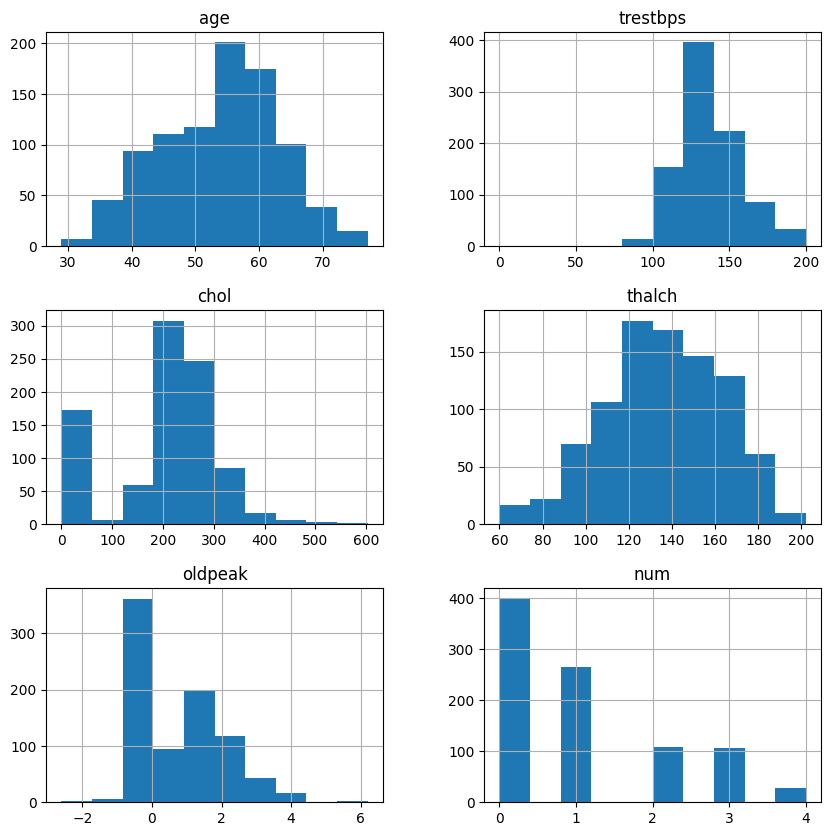

In [10]:
df.hist(figsize=(10,10),bins=10)
plt.show()

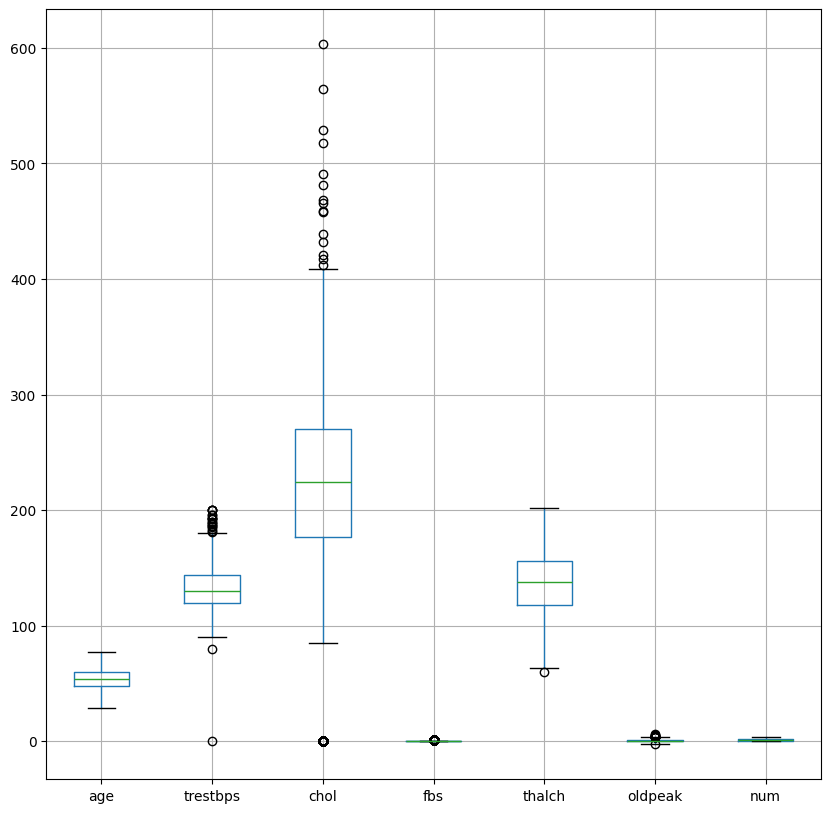

In [11]:
df.boxplot(figsize=(10,10))
plt.show()

In [12]:
cat_cols=df.select_dtypes(include=['object']).columns.tolist()
num_cols=df.select_dtypes(include=['float64','int64']).columns.tolist()

# Correlatino matrix for numerical columns
num_corr=df[num_cols].corr()

# Display the correlation matrix
print("Correlation matrix for numerical variables:")
display(num_corr)

Correlation matrix for numerical variables:


,age,trestbps,chol,thalch,oldpeak,num
age,1.000000,0.253709,-0.100059,-0.327868,0.243280,0.326227
trestbps,0.253709,1.000000,0.117392,-0.132841,0.168160,0.136581
chol,-0.100059,0.117392,1.000000,0.198074,0.030052,-0.239065
thalch,-0.327868,-0.132841,0.198074,1.000000,-0.140423,-0.322632
oldpeak,0.243280,0.168160,0.030052,-0.140423,1.000000,0.438834
num,0.326227,0.136581,-0.239065,-0.322632,0.438834,1.000000


In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[df.select_dtypes(include=['int64', 'float64']).columns] = scaler.fit_transform(df.select_dtypes(include=['int64', 'float64']))

In [14]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score,precision_score,f1_score, recall_score, roc_auc_score

In [16]:
df = pd.get_dummies(df, drop_first=True)
df.isnull().any()

,0
age,False
trestbps,False
chol,False
fbs,False
thalch,False
oldpeak,True
num,False
sex_Male,False
cp_atypical angina,False
cp_non-anginal,False


In [17]:
df['num']

,num
0,-0.880901
1,-0.880901
2,-0.880901
3,-0.880901
4,-0.880901
...,...
903,2.615717
904,2.615717
905,2.615717
906,2.615717


In [18]:
df['num'] = (df['num'] > 0).astype(int)
X = df.drop('num', axis=1)
y = df['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [20]:
imputer = SimpleImputer(strategy='mean')

In [21]:
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [22]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred)

In [23]:
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('ROC-AUC:', roc_auc)

Accuracy: 0.8021978021978022
Precision: 0.7938203771537106
Recall: 0.8021978021978022
F1 Score: 0.7718657181744429
ROC-AUC: 0.6446611253196932


In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [25]:
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('ROC-AUC:', roc_auc)

Accuracy: 0.8021978021978022
Precision: 0.7938203771537106
Recall: 0.8021978021978022
F1 Score: 0.7718657181744429
ROC-AUC: 0.6446611253196932


In [26]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned Accuracy: 0.7857142857142857


In [31]:
import matplotlib.pyplot as plt

# Print the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Feature importance
importance = best_model.feature_importances_
for i, feature in enumerate(X.columns):
    print(f"{feature}: {importance[i]}")

[[131   5]
 [ 31  15]]
age: 0.11852263802430817
trestbps: 0.05074005633731828
chol: 0.3138815036489042
fbs: 0.0
thalch: 0.06928773496893474
oldpeak: 0.34713799364971215
sex_Male: 0.0
cp_atypical angina: 0.0
cp_non-anginal: 0.0
cp_typical angina: 0.0
restecg_normal: 0.0
restecg_st-t abnormality: 0.0
exang_True: 0.10043007337082238
exang_FALSE: 0.0
exang_TURE: 0.0
slope_flat: 0.0
slope_upsloping: 0.0
thal_normal: 0.0
thal_reversable defect: 0.0


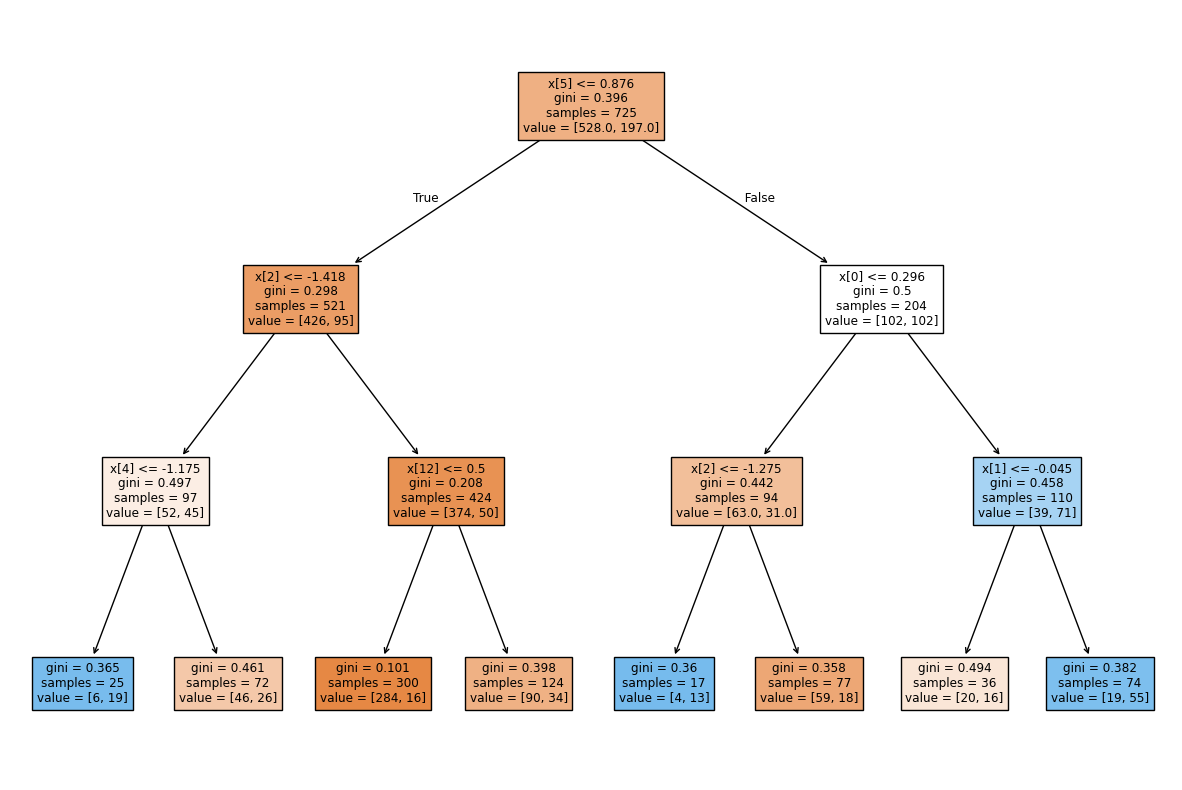

In [32]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(best_model, filled=True)
plt.show()

In [28]:
# Evaluate the model performance using the obtained metrics

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

# Precision
precision = precision_score(y_test, y_pred, average='weighted')
print('Precision:', precision)

# Recall
recall = recall_score(y_test, y_pred, average='weighted')
print('Recall:', recall)

# F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')
print('F1 Score:', f1)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred)
print('ROC-AUC:', roc_auc)

Accuracy: 0.8021978021978022
Precision: 0.7938203771537106
Recall: 0.8021978021978022
F1 Score: 0.7718657181744429
ROC-AUC: 0.6446611253196932


1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

Common Hyperparameters of Decision Tree:

1. max_depth:
   - Maximum depth of tree
   - Small value -> underfitting
   - Large value -> overfitting

2. min_samples_split:
   - Minimum samples required to split a node
   - Higher value -> simpler model

3. min_samples_leaf:
   - Minimum samples in a leaf node
   - Prevents overfitting

4. criterion:
   - Method to measure split quality
   - Types: 'gini', 'entropy'

5. max_features:
   - Number of features used for splitting
   - Helps reduce overfitting

Conclusion:
Proper tuning improves accuracy and prevents overfitting.
"""

2. What is the difference between the Label encoding and One-hot encoding?

Label Encoding:
- Assigns numbers to categories
- Example: Red=0, Blue=1, Green=2
- Problem: creates false order

One-Hot Encoding:
- Creates binary columns
- Example:
  Red   -> [1,0,0]
  Blue  -> [0,1,0]
  Green -> [0,0,1]
- No order issue

Difference:
- Label Encoding -> 1 column
- One-Hot Encoding -> multiple columns

Conclusion:
- Use Label Encoding for ordered data
- Use One-Hot Encoding for unordered data